
# **Academic Integrity and Learning Statement**

By submitting my work, I confirm that:

- The code, analysis, and documentation in this notebook are my own work and reflect my own understanding.
- I am prepared to explain all code and analysis included in this submission.

If I used assistance (e.g., AI tools, tutors, or other resources), I have:

- Clearly documented where and how external tools or resources were used in my solution.
- Included a copy of the interaction (e.g., AI conversation or tutoring notes) in an appendix.

I acknowledge that:

- I may be asked to explain any part of my code or analysis during evaluation.
- Misrepresenting assisted work as my own constitutes academic dishonesty and undermines my learning.


# **Unit B: Data Cleaning**
#### **Introduction**
The goal of this unit is to get familiar with the strengths and weaknesses of the data set and prepare it for in-depth analysis. 

We will perform several data cleaning steps in this unit. We will mainly be focusing on removing duplicated rows and filling in missing values. Several strategies will be used to adress the missing values.

#### **Table of content**

0. Importing the Data  
1. Checking and Removing Duplicated Rows  
2. Checking for Missing Values  
   - a) Assessing the Percentage of Missing Values  
   - b) Visualizing Missing Values Using the `missingno` Library  
   - c) Visualizing Missing Values Using Bar Plots and Violin Plots  
3. Addressing Missing Values  
   - a) Removing Empty Rows / Columns  
   - b) Filling in Missing Values Using the Most Frequent Value in the Column  
   - c) Filling Missing Values Using Related Columns  
   - d) Filling Missing Values Using Common Knowledge  
   - e) Filling Missing Text Values by Indicating the Field Is Missing  
   - f) Removing Columns That Still Contain > 95% Missing Values  


## **0) Importing the data**

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Import the data as a pandas DataFrame into your notebook
df = pd.DataFrame(pd.read_pickle("data_385k.pkl", compression="zip"))

## **1) Checking and removing duplicated rows**

Let's now have a look at the presence of duplicated rows, and let's remove any duplicated rows if they exist.

In [3]:
# Are there any duplicated data in the data frame?
print("there are", df.duplicated().sum(), "duplicated rows in the data frame")

there are 10500 duplicated rows in the data frame


In [4]:
# Remove all duplicated rows:
print("old data frame shape:", df.shape)

df = df.drop_duplicates()

# Shape of the remaining data:
print("new data frame shape:", df.shape)

old data frame shape: (385384, 99)
new data frame shape: (374884, 99)


## **2) Checking for missing values**

### **2a) Assessing the percentage of missing values**
Let's start by getting the number (and percentage) of missing values for each column, and let's then plot the columns sorted according to their percentage of missing values. 

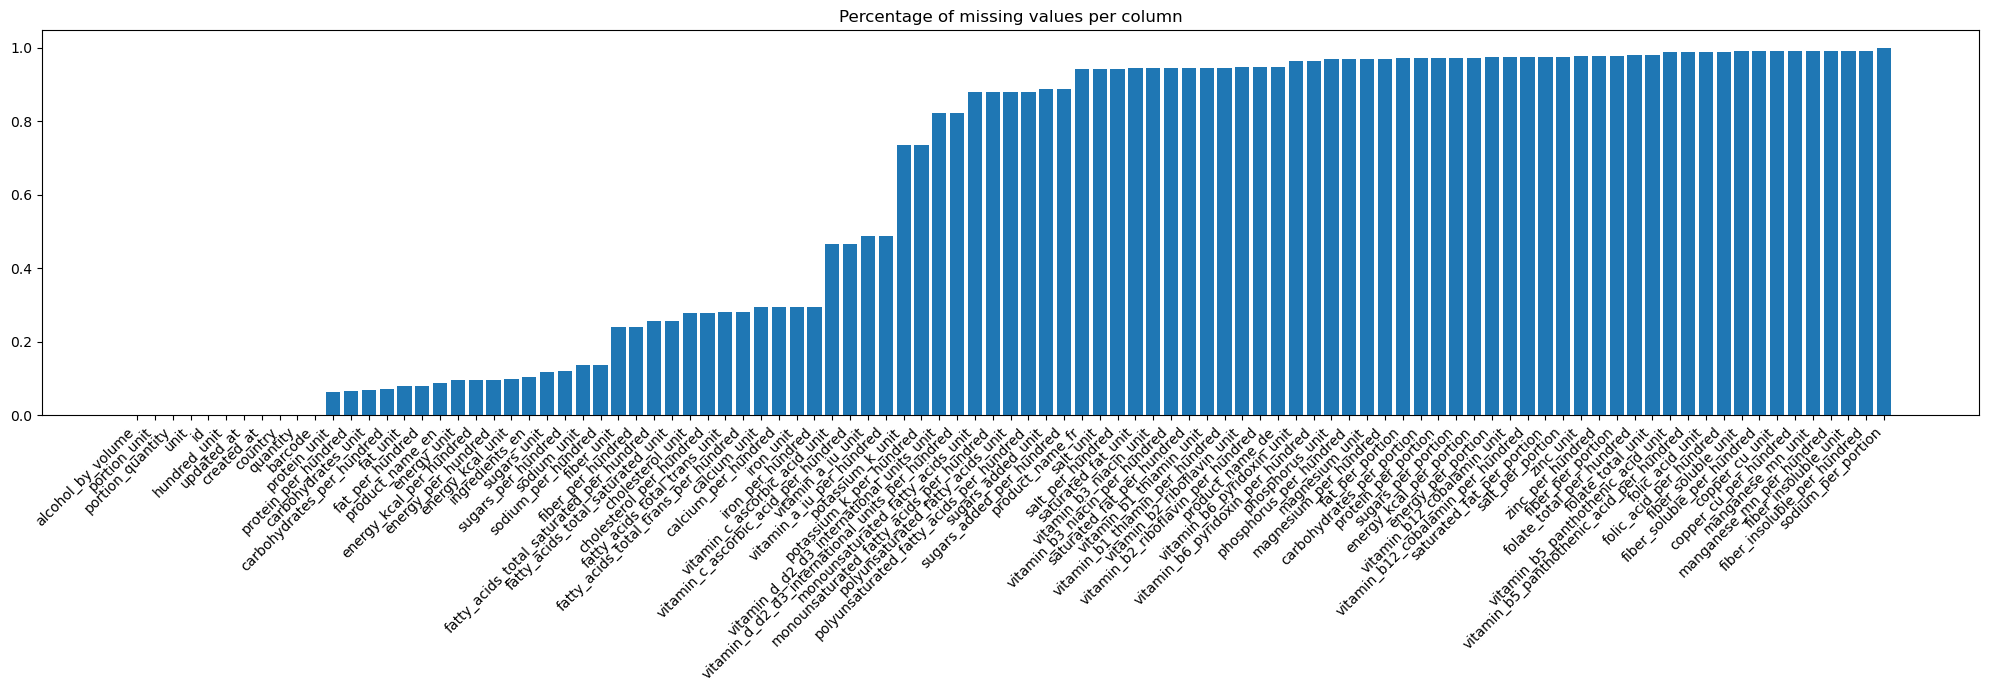

In [5]:
# Print the number of missing values and the precentage of missing values for each column
missing = pd.DataFrame(df.isna().sum(), columns=["n_missing"])
missing["percent_missing"] = missing.n_missing / len(df)

# plot the columns sorted according to their percentage of missing values
plt.figure(figsize=(25, 5)) 
plt.bar(x=missing.sort_values("percent_missing").index, height=missing.sort_values("percent_missing").percent_missing)
plt.title("Percentage of missing values per column")
plt.xticks(rotation=45, ha="right")
plt.show()

We observe that some columns have an extremely high percentage of missing values. Let's display the 25 columns that have the most missing values to gain better understanding of the data.

In [6]:
# Display a table with the missing values for the 25 columns containing the most missing values

pd.set_option('display.max_rows', None)
missing.sort_values("percent_missing", ascending=False)

,n_missing,percent_missing
sodium_per_portion,374131,0.997991
fiber_insoluble_per_hundred,371375,0.990640
fiber_insoluble_unit,371374,0.990637
manganese_mn_per_hundred,371350,0.990573
manganese_mn_unit,371347,0.990565
copper_cu_per_hundred,371273,0.990368
copper_cu_unit,371273,0.990368
fiber_soluble_per_hundred,371057,0.989792
fiber_soluble_unit,371055,0.989786
folic_acid_per_hundred,370428,0.988114


In [4]:
pd.set_option('display.max_rows', 10)

A lot of the columns have more than 95% of missing values. This is something we will need to adress further on. 
### **2b) Missingno library**
In the meanwhile, let's try out the missingno library to help visualize where the missing values are in the data frame. 

In [7]:
import missingno as msno
%matplotlib inline

<AxesSubplot:>

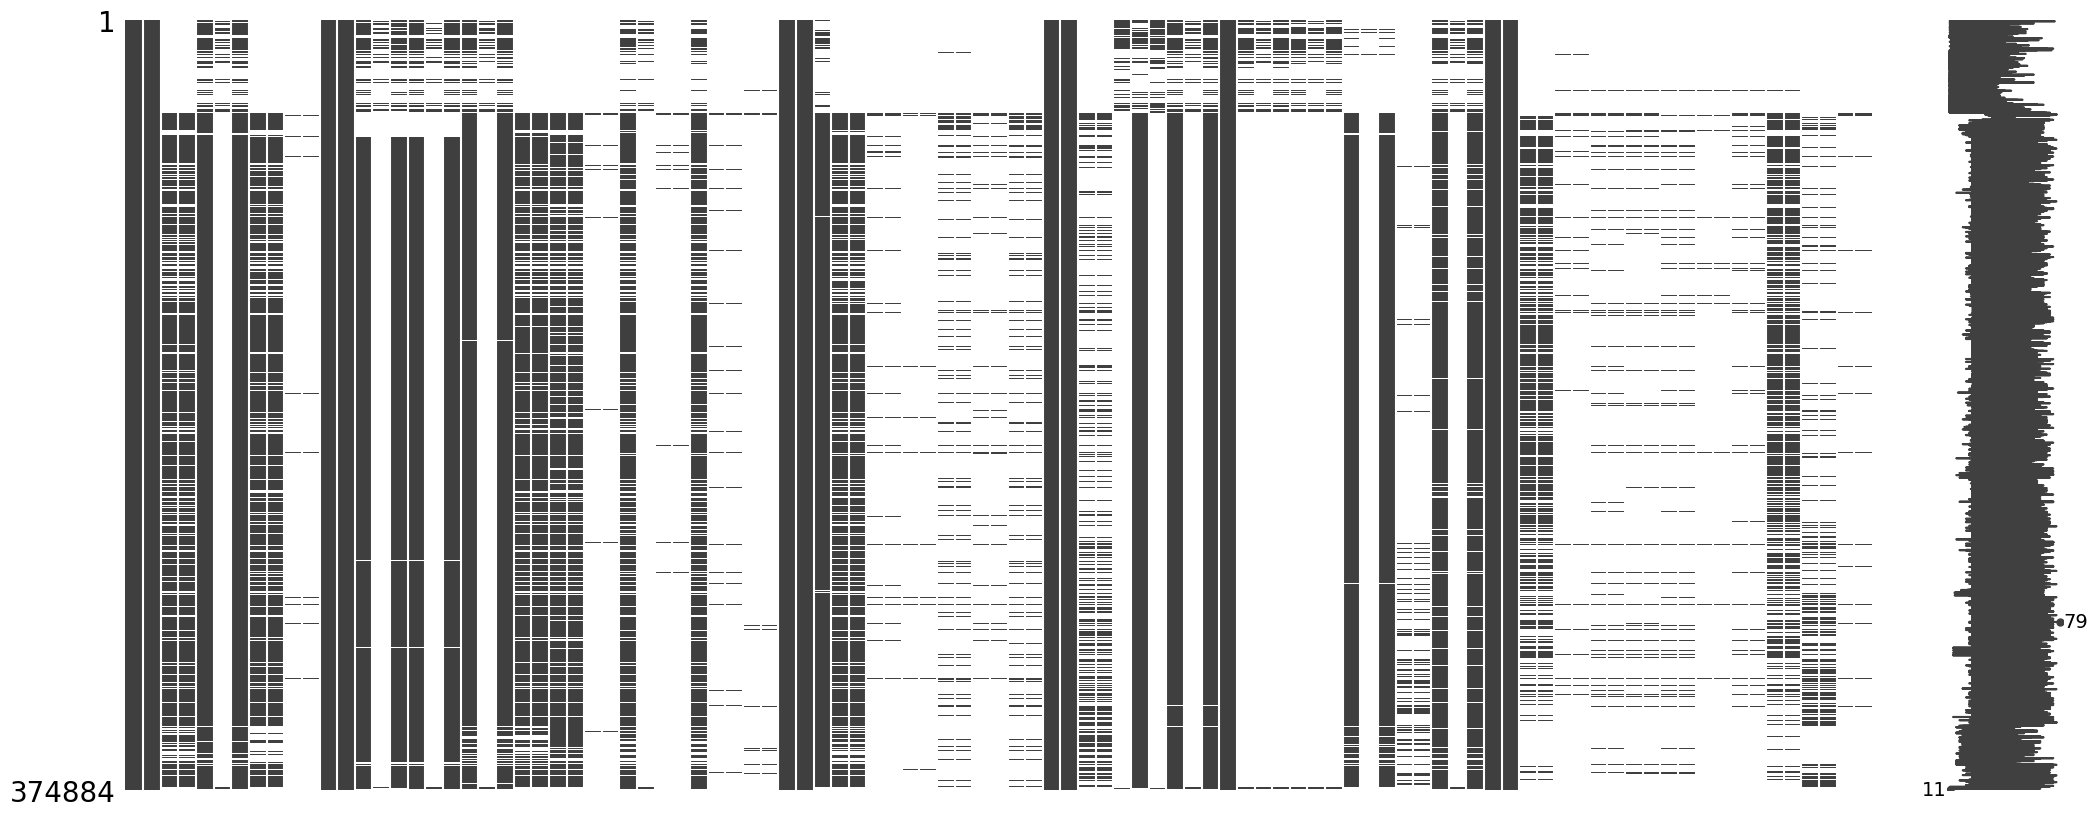

In [8]:
msno.matrix(df)

### **2c) Missing data visualizations**

To better understand the data, let's see which type of column contains the most missing values and if there are differences in between different variable types. To do this, let's plot the number of missing values in the per_hundred, per_portion and per_unit columns. 

I will start by making a bar plot, and then a violin plot for each column type.

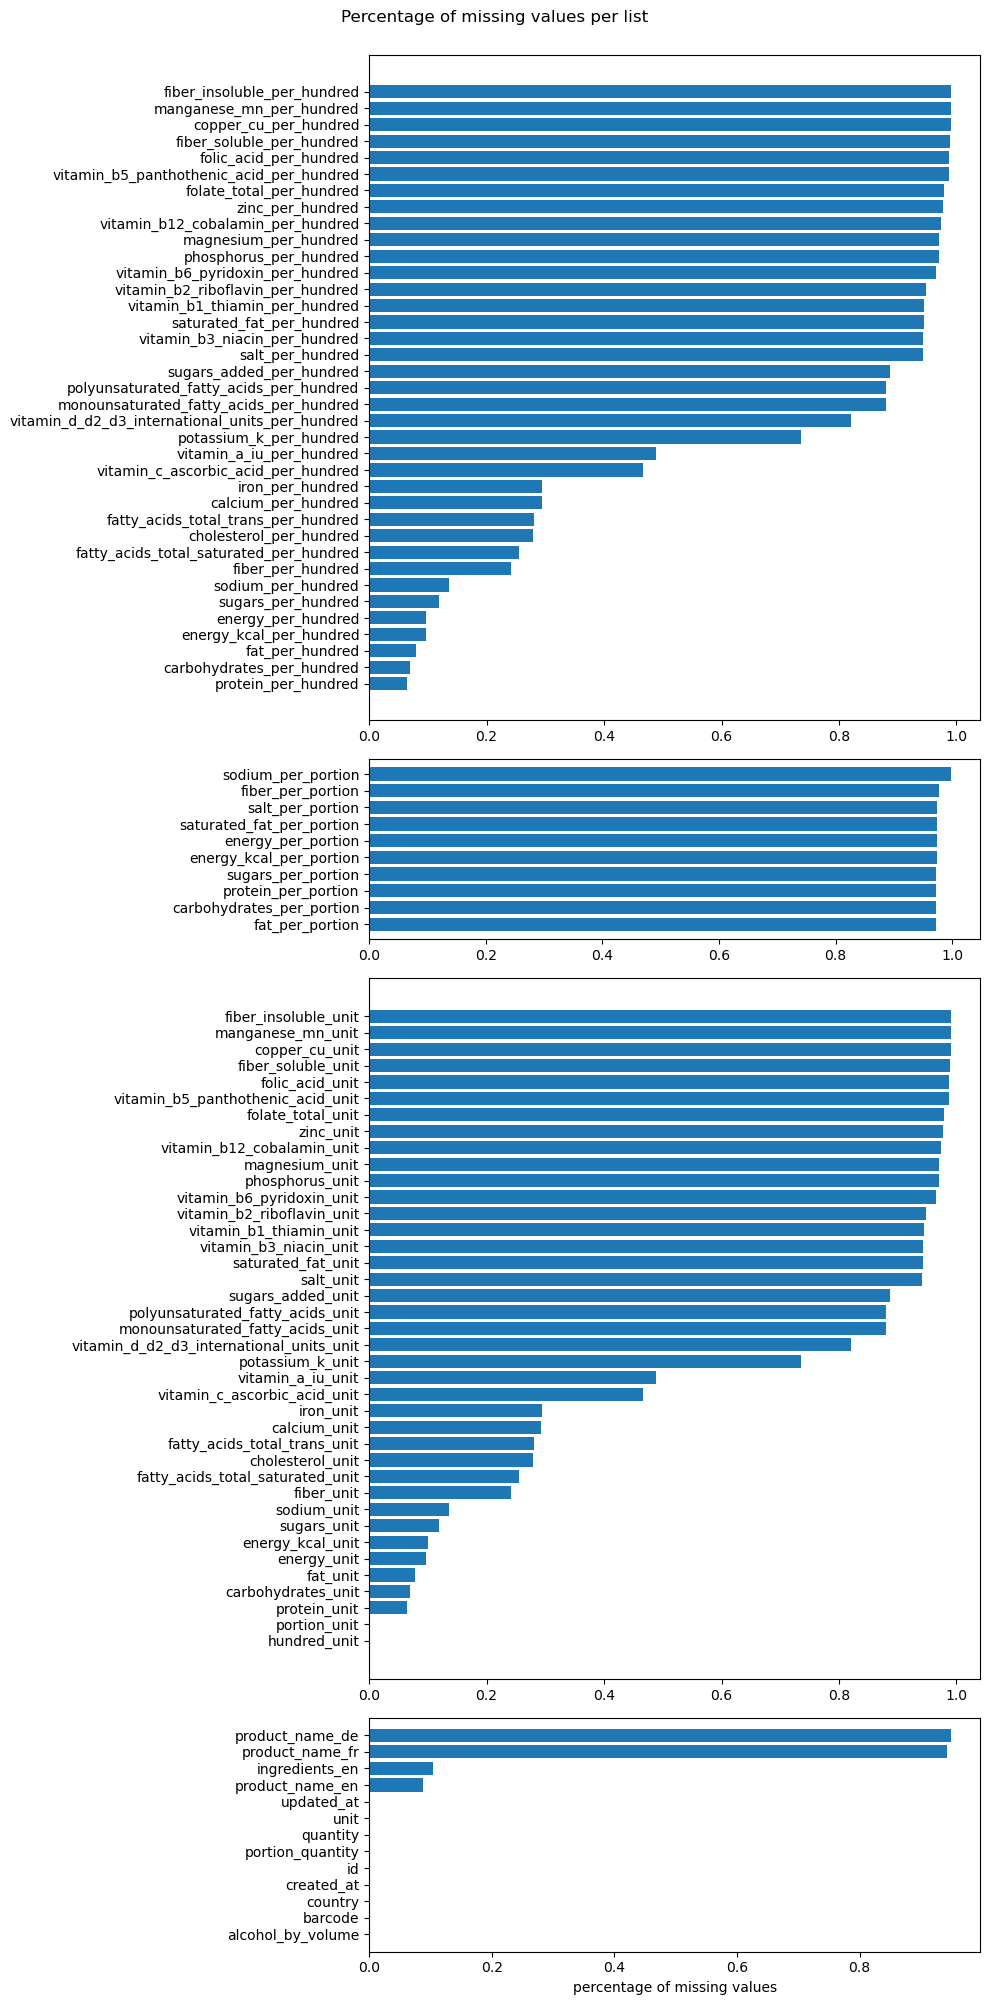

In [9]:
# Create 3 lists that hold the columns ending with per_hundred, per_portion and _unit and one list that has all the other columns
col_hundred = df.filter(regex="_per_hundred$").columns
col_portion = df.filter(regex="_per_portion$").columns
col_unit = df.filter(regex="_unit$").columns
col_other = [col for col in df.columns if col not in col_hundred and col not in col_portion and col not in col_unit]

# compute the length of each list to allocate the correct size to the subplots:
n0 = len(col_hundred)
n1 = len(col_portion)
n2 = len(col_unit)
n3 = len(col_other)

fig, axes = plt.subplots(4, 1, figsize=(10,20), gridspec_kw={"height_ratios": [n0, n1, n2, n3]})
axes[0].barh(missing.loc[col_hundred, "percent_missing"].sort_values().index, missing.loc[col_hundred, "percent_missing"].sort_values())
axes[1].barh(missing.loc[col_portion, "percent_missing"].sort_values().index, missing.loc[col_portion, "percent_missing"].sort_values())
axes[2].barh(missing.loc[col_unit, "percent_missing"].sort_values().index, missing.loc[col_unit, "percent_missing"].sort_values())
axes[3].barh(missing.loc[col_other, "percent_missing"].sort_values().index, missing.loc[col_other, "percent_missing"].sort_values())

plt.xlabel("percentage of missing values")
fig.suptitle("Percentage of missing values per list", y=1)
plt.tight_layout()
plt.show()

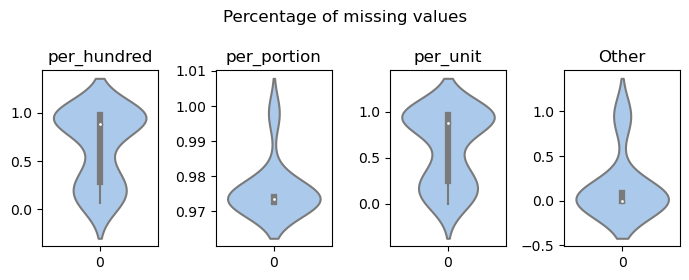

In [10]:
# Here, I am making a violin plot for each list with the average percentage of missing values
fig, axes = plt.subplots(1, 4, figsize=(7, 2.5))
sns.set_palette("pastel")
sns.violinplot(data=missing.loc[col_hundred, "percent_missing"], ax=axes[0])
sns.violinplot(data=missing.loc[col_portion, "percent_missing"], ax=axes[1])
sns.violinplot(data=missing.loc[col_unit, "percent_missing"], ax=axes[2])
sns.violinplot(data=missing.loc[col_other, "percent_missing"], ax=axes[3])
axes[0].set_title("per_hundred")
axes[1].set_title("per_portion")
axes[2].set_title("per_unit")
axes[3].set_title("Other")
plt.tight_layout()
fig.suptitle("Percentage of missing values", y=1.1)
plt.show()

We see that, especially in the per_hundred and per_unit columns, there are a lot of missing values. Interestingly, the distribution seems to be similar for those two columns, we could hypothetize that a lot of rows have information neither in the per_hundred nor in the per_unit row.

## **3) Adressing the missing values**

### **3a) Removing empty rows / columns**

Let's start by removing rows and columns that are completely empty.

In [11]:
# remove rows and columns that are completely empty

print("data frame shape before removing missing values", df.shape)

df = df.dropna(axis=0, how="all")
df = df.dropna(axis=1, how="all")

print("data frame shape after removing missing values:", df.shape)

data frame shape before removing missing values (374884, 99)
data frame shape after removing missing values: (374884, 99)


We see that this approach didn't remove any rows or columns, as we didn't have any row or column that is completely empty. 

### **3b) Filling in missing values using the most frequent value in the column**
Let's start filling in the missing values. For the unit columns, we can fill up the missing values using the most frequent value in the column

In [12]:
# Get the most frequent value per column
top = df[col_unit].mode(axis=0).iloc[0]

# fill in the missing values: 
df[col_unit] = df[col_unit].fillna(top)

# Make sure that it worked
print("there are now", df[col_unit].isna().sum().sum(), "missing values in the per_unit columns")

there are now 0 missing values in the per_unit columns


### **3c) Filling up missing values using related columns**
Another strategy is to fill up the missing values using other columns that hold similar information. Let's apply this approach on the product_name_en column. We will fill up this column using the product name in french or in german. As this approach doesn't fill in all of the missing values, we will then fill the remaining empty values with "no product name

In [13]:
# First calculate the number of rows that are empty:
empty_origin_en = df.product_name_en.isna().sum()
print("originally, there are " , empty_origin_en, "rows that don't have a product name in english")

#Fill using the product name fr and de
df["product_name_en"] = df["product_name_en"].fillna(df["product_name_fr"])
empty_fr = df.product_name_en.isna().sum()
print("Using the french column filled up", empty_origin_en - empty_fr, "rows")

df["product_name_en"] = df["product_name_en"].fillna(df["product_name_de"])
empty_de = df.product_name_en.isna().sum()
print("using the german column filled up", empty_origin_en - empty_de, "rows")

# Fill up remaining empty rows with "no product name".
df["product_name_en"] = df["product_name_en"].fillna("No Product Name")

originally, there are  33165 rows that don't have a product name in english
Using the french column filled up 11619 rows
using the german column filled up 14299 rows


### **3d) Filling up missing values using common knowledge**
Let's now fill missing values based on common knowledge. For instance, the column named iron_per_hundred has about 30% missing values. This could be because the products are iron-free. Thus, we will replace all missing values with 0.

In [14]:
# Let's replace all missing values with 0 
print("there are originally", df.iron_per_hundred.isna().sum(), "rows without an iron_per_hundred value")

df.iron_per_hundred = df.iron_per_hundred.fillna(value=0)

print("there are now", df.iron_per_hundred.isna().sum(), "rows without an iron_per_hundred value")


there are originally 110495 rows without an iron_per_hundred value
there are now 0 rows without an iron_per_hundred value


### **3e) Filling up missing values by indicating the fields are missing**
For text-based columns, we can simply replace the missing value with something that shows that the value is missing. We will do this for the column ingredients_en that has 10% missing values. We will replace the missing value with the term "ingredient_missing".

In [15]:
print("there are originally", df.ingredients_en.isna().sum(), "missing ingredients")
print("this corresponds to", df.ingredients_en.isna().sum() / len(df) * 100, "% of the data")

df.ingredients_en = df.ingredients_en.fillna(value="ingredient_missing")

print("there are now", df.iron_per_hundred.isna().sum(), "missing ingredients")


there are originally 38958 missing ingredients
this corresponds to 10.392014596515189 % of the data
there are now 0 missing ingredients


### **3f) Removing columns that still contain >95% missing values**
Let's assume that we want to build up a data analysis pipeline based on at least 20'000 rows of non missing data. This amounts to 5% of the data set. Thus, we will drop columns that still contain more than 95% of missing values!

In [16]:
print("original shape:", df.shape)

# Number of missing values that correspond to 95% of rows
threshold_95 = round(0.05*len(df))

#drop those columns
df = df.dropna(axis=1, thresh=threshold_95)

print("new shape:", df.shape)

original shape: (374884, 99)
new shape: (374884, 77)


# **Unit C: Preliminary Exploratory Data Analysis (EDA)**

#### **Introduction**

Now that we have removed missing values and duplicated information, we will start exploring the variables in our data in more detail. This will allow us to gain a better understanding of the limitations and inconsistencies in our data set. 

Once we have explored the data, will perform additional cleaning steps to adress inconsistencies and errors in our data, and remove extreme values. At the end of the unit, we will save the cleaned data as a new pickle file and make sure to use this cleaned data for further analysis later on. 

#### **Table of Content**

**A) Data Visualization**
1) Visualizing the categorical variables
2) Visualizing the numerical variables

**B) Cleaning the data**
1) Removing improbable values and errors
    - a) Adressing wrong values in the per_hundred column
    - b) Adressing inconsistencies and errors using related columns
2) Removing outliers

**C) Saving the data**


## **A) Data Visualization**

### **1) Visualizing the categorical variables**

Let's start by visualizing the categorical variables and understanding the different values these variables can have. We will focus on the country and unit variables and visualize them using bar plots.

In [17]:
df.dtypes

# Find the levels in the variable country
print(df["country"].value_counts())

# Find the levels in the variable unit
print(df["unit"].value_counts())

US    328289
CH     33117
DE     10639
IT      2719
FR       118
AT         1
UK         1
Name: country, dtype: int64
g       324240
ml       48941
cl         787
l          495
kg         358
dl          29
?           22
Floz         5
Oz           4
Lb           3
Name: unit, dtype: int64


/home/ruop/miniconda3/envs/adsml/lib/python3.9/site-packages/pandas/plotting/_core.py:1746: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


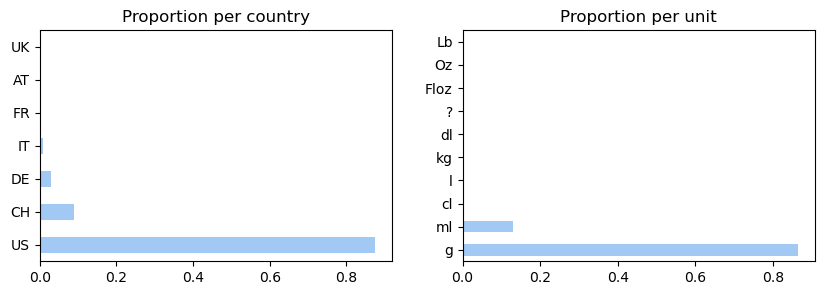

In [18]:
# Proportion of samples in each categorical level for the variable country:
proportion_country = df.groupby("country").size()/len(df["country"])

# Alternative:
proportion_country = df["country"].value_counts(normalize=True)

# Proportion of samples in each categorical level for the variable unit:
proportion_unit = df["unit"].value_counts(normalize=True)

fig, axes = plt.subplots(1,2, figsize=(10,3))

proportion_country.plot.barh(ax=axes[0])
axes[0].set_title("Proportion per country")
proportion_unit.plot.barh(ax=axes[1])
axes[1].set_title("Proportion per unit")
plt.show()

We observe that a large majority of the entries are listed as having US as their country. Interestingly, the vast majorities of items are listed in grams (metric system). 

### **2) Visualizing the numerical variables**

For the numerical variables, we will provide descriptive statistics and create some plots to gain a better understanding of the information these variables hold.

In [19]:
# Define the numerical columns
num_col = df.select_dtypes(include=["float64", "int64"]).columns

In [20]:
# Start by displaying statistics for the different columns
df[num_col].describe()

,alcohol_by_volume,calcium_per_hundred,carbohydrates_per_hundred,cholesterol_per_hundred,energy_kcal_per_hundred,energy_per_hundred,fat_per_hundred,fatty_acids_total_saturated_per_hundred,fatty_acids_total_trans_per_hundred,fiber_per_hundred,...,saturated_fat_per_hundred,sodium_per_hundred,sugars_added_per_hundred,sugars_per_hundred,vitamin_a_iu_per_hundred,vitamin_b1_thiamin_per_hundred,vitamin_b2_riboflavin_per_hundred,vitamin_b3_niacin_per_hundred,vitamin_c_ascorbic_acid_per_hundred,vitamin_d_d2_d3_international_units_per_hundred
count,374884.000000,264854.000000,348551.000000,270282.000000,338574.000000,338571.000000,345260.000000,279151.000000,269607.000000,284479.000000,...,20910.000000,323824.000000,42478.000000,330154.000000,192093.000000,20402.000000,19683.000000,21117.000000,200006.000000,67024.000000
mean,0.027911,116.647405,34.005231,58.981358,272.484231,1139.512786,12.705385,4.943331,0.034861,2.925621,...,5.904191,1.402169,23.993521,16.992009,494.236708,0.925326,1.680103,9.846486,15.704688,14.186515
std,0.769066,2557.910159,40.848987,1934.718972,258.287614,1079.676340,19.508870,8.500435,1.285369,5.892698,...,8.314095,69.838205,25.616094,31.176491,2445.251154,13.490207,142.610273,73.079281,583.641608,73.262518
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,6.670000,0.000000,89.000000,372.380000,0.000000,0.000000,0.000000,0.000000,...,0.500000,0.030000,5.200000,1.670000,0.000000,0.000000,0.200000,3.000000,0.000000,0.000000
50%,0.000000,36.000000,23.530000,0.000000,267.000000,1117.130000,5.450000,2.000000,0.000000,1.600000,...,2.000000,0.260000,16.000000,6.450000,0.000000,0.000000,0.330000,4.880000,0.000000,0.000000
75%,0.000000,102.000000,60.000000,25.000000,400.000000,1673.600000,20.000000,7.140000,0.000000,3.600000,...,9.000000,0.570000,36.600000,25.140000,352.000000,1.000000,0.590000,8.330000,3.900000,0.000000
max,57.900000,684000.000000,6400.000000,250000.000000,39600.000000,165686.400000,3200.000000,1000.000000,615.380000,1730.000000,...,100.000000,25833.330000,1100.000000,5800.000000,333333.000000,1111.000000,20000.000000,6785.710000,210000.000000,5000.000000


We already observe several things:
- For alcohol_by_volume: most values are 0 (most items don't contain alcohol), with a very low mean and a high standard deviation. In this case, it would maybe make sense to plot only the columns containing alcohol. 
- the ID column is a numerical column (it contains numbers) but acts more as a categorical variable. It wouldn't make sense to plot a histogram here. 
- Similar to alcohol_by_volume, a lot of the per_hundred columns have a very high amount of values that are at 0. It will be difficult to plot them all, perhaps a solution would be to plot only the values above 0. 
- the column quantity seems to have a more interesting distribution, in this case making a boxplot would make sense. However, it seems to also have outliers (the max is at 230000 which seems too high). 

Let's now create **boxplots** for each column to display the statistical information.

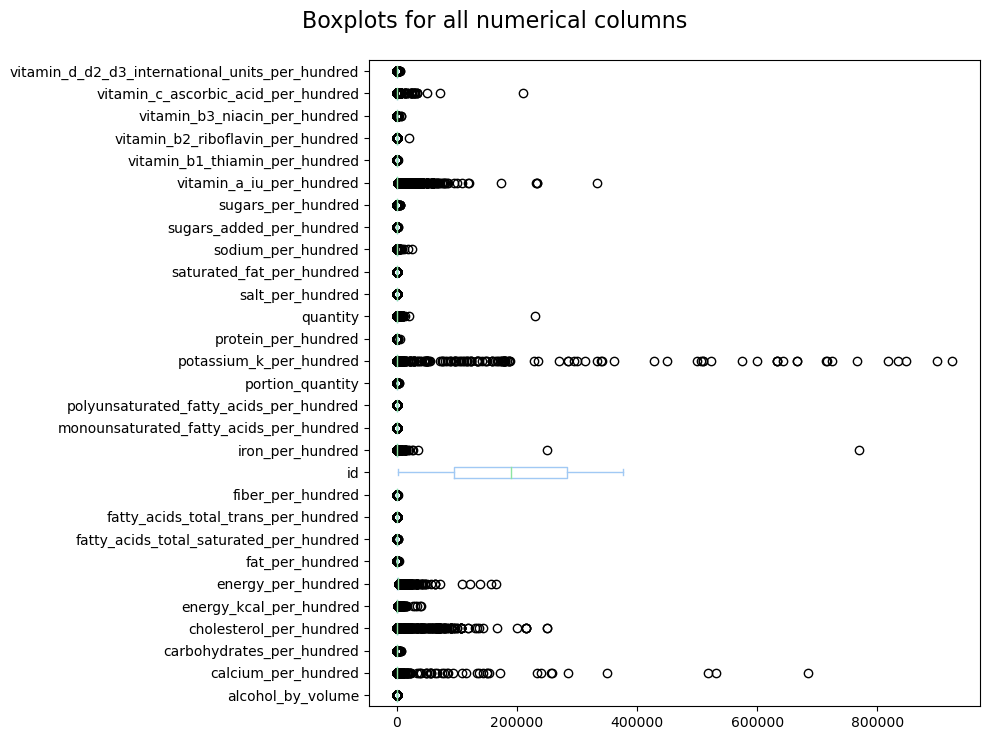

In [21]:
# First create boxplot for each column (will display the statistical values)
df[num_col].plot.box(figsize=(10,7), vert=False)
plt.tight_layout()
plt.suptitle("Boxplots for all numerical columns", y=1.05, size=16)
plt.show()

As expected, the boxplots do not make a lot of sense for most of these variables. We do however observe that there are very clear outliers for several of the per_hundred columns that we could remove.

Alternatively, we can display the data as **histograms** to see the information in a different way. 

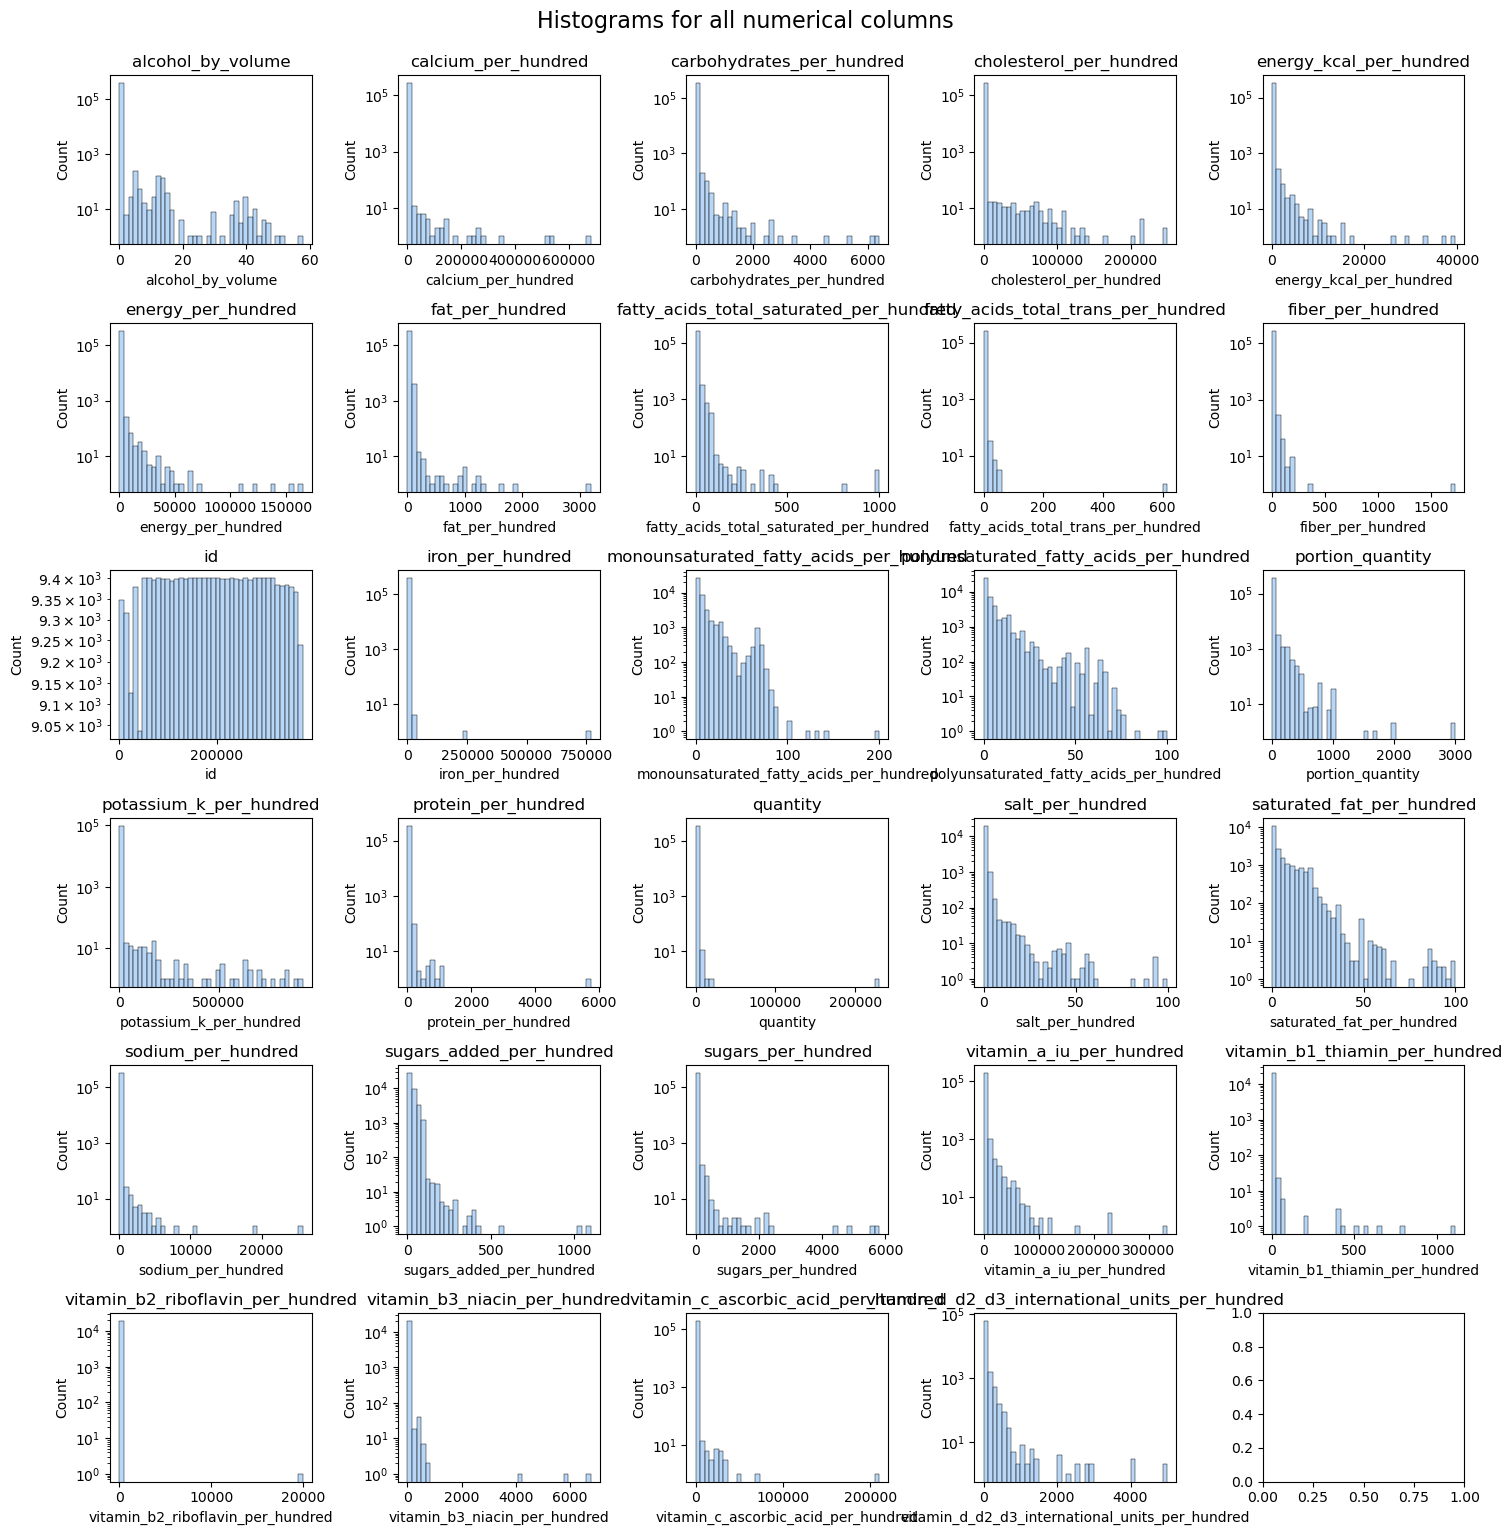

In [22]:
fig, axes = plt.subplots(6, 5, figsize=(15, 15))
axes = axes.flatten()

for ax, col in zip(axes, num_col):
    sns.histplot(df[col], ax=ax, bins=40)
    ax.set_title(col)
    ax.set_yscale("log")


plt.tight_layout()
plt.suptitle("Histograms for all numerical columns", y=1.02, size=16)
plt.show()

These plots also highlight that the majority of the data in several columns is close to zero. Additionally, a lot of values skew the histograms to the right, rendering the visualization complicated. Setting the y scale to a log scale helps with the visualization.

let's replot the data with all values above zero to have a better understanding of the distributions

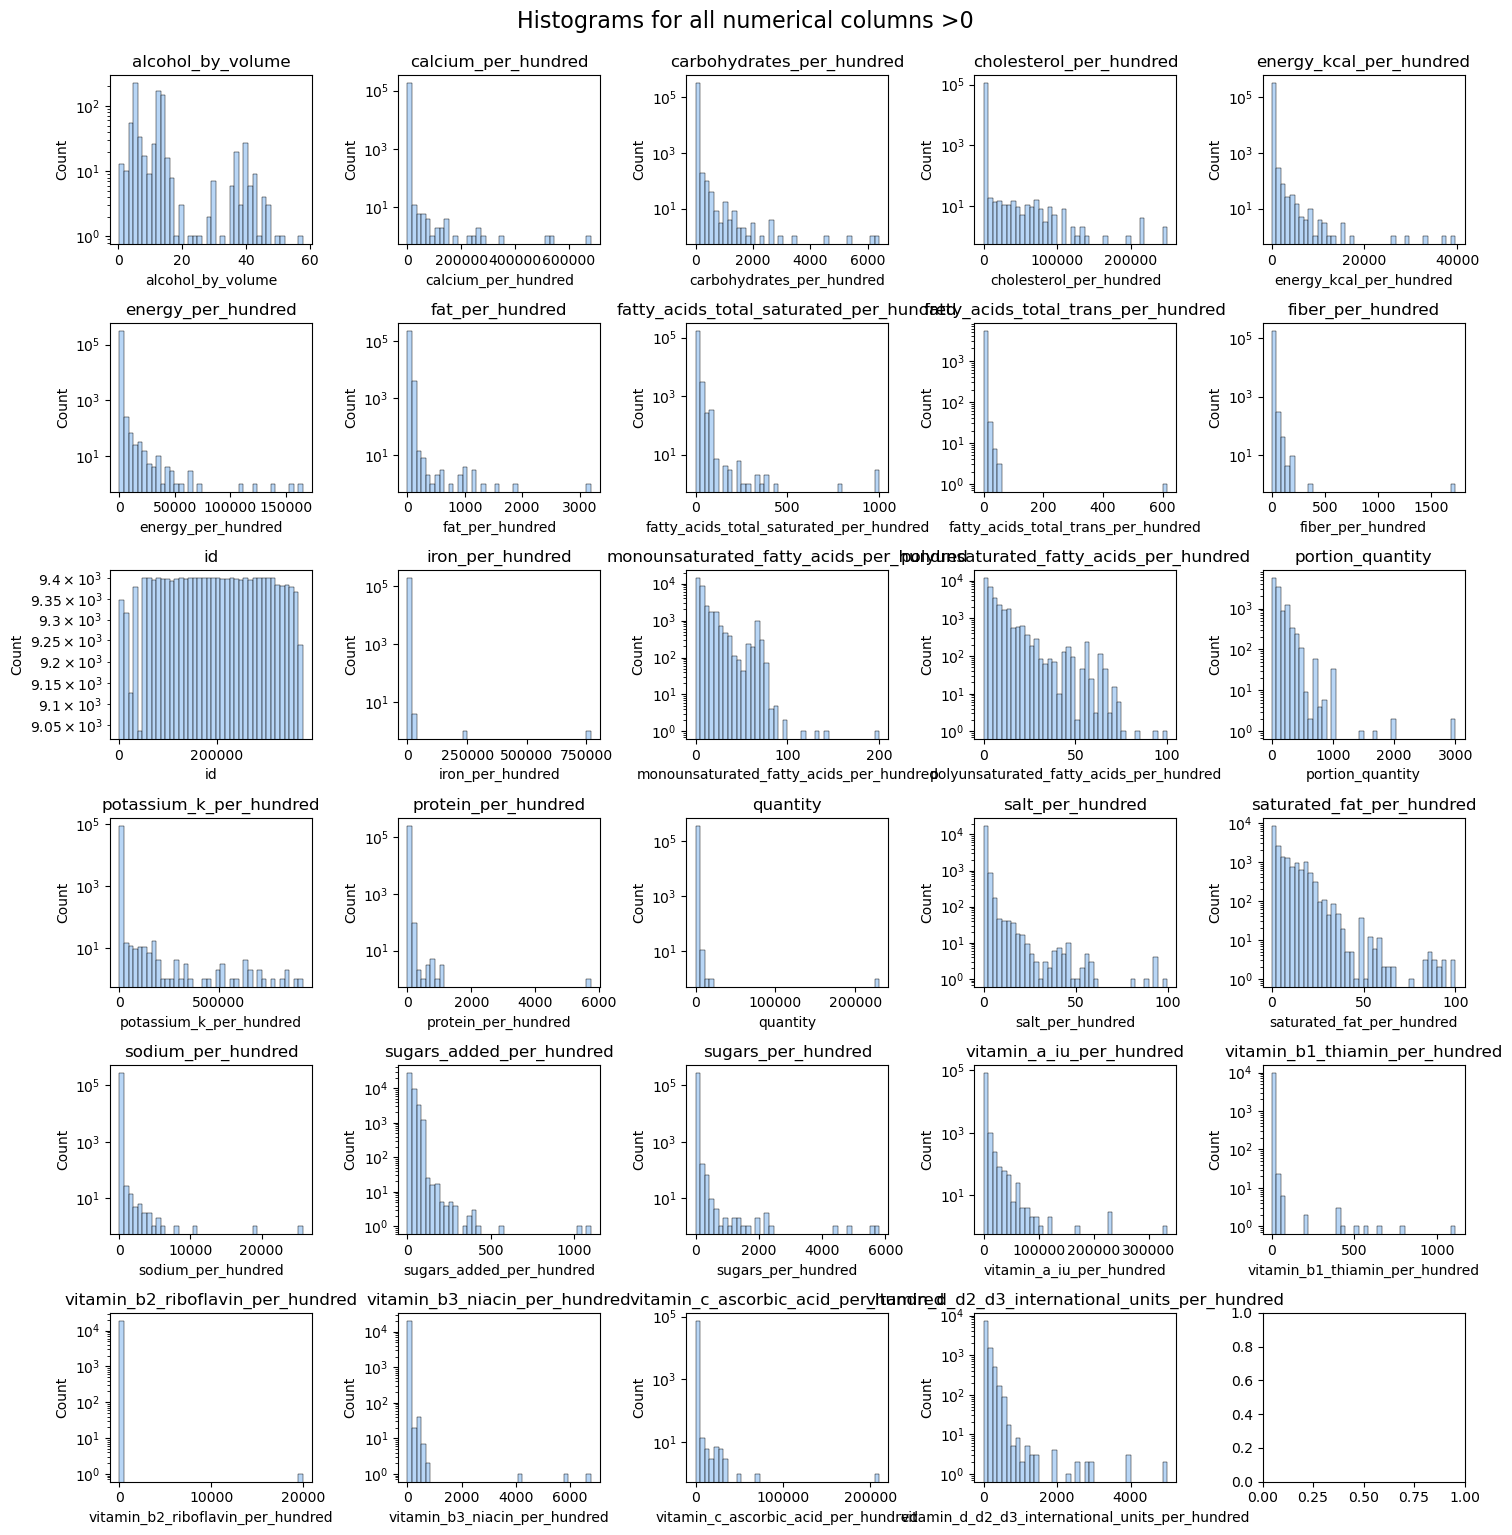

In [23]:
fig, axes = plt.subplots(6, 5, figsize=(15, 15))
axes = axes.flatten()

for ax, col in zip(axes, num_col):
    sns.histplot(df.loc[(df[col]!=0), col], ax=ax, bins=40)
    ax.set_title(col)
    ax.set_yscale("log")


plt.tight_layout()
plt.suptitle("Histograms for all numerical columns >0", y=1.02, size=16)
plt.show()

This improves the visualization a lot. We still however observe that there are a lot of "extreme" values in the data that skew the distributions to the right. This is something we can adress later on. 

## **Cleaning the data**

Now that we have a better understanding of the data, we can start by cleaning it. We will take several approaches for this:
- Removing improbable values / errors
- Removing extreme values (outlier removal)

### **1) Removing improbable values and errors**

Some values in our data set are clearly errors or are unrealistic. We can start adressing this. 
There are several strategies we can take: 
- for the per_hundred columns, we can define a filter with a maximal value allowed depending on the unit (a food item cannot have more than 100 grams of sugar per hundred grams of food for instance"
- we can create filters based on **related columns**. Some columns in our data set are related to each other or pose constraints on one another. Unfortunately, this may also give rise to inconsistencies, but we can use the relationship between columns to filter out errors.

#### **1a) Adressing wrong values in the per_hundred column**
We will extract the name of the item in the per_hundred column and use this to find its corresponding unit.
Depending on the unit, we will then define a max limit and see if the value is below this limit. If not, we will flag the item for removal. 

In [24]:
# Extract the name of the per_hundred column without the _per_hundred
col_hundred_clean = df.filter(regex="_per_hundred").columns
names = col_hundred_clean.str.replace('_per_hundred', '', regex=False)

# Initialize the filter
unit_filter = pd.DataFrame(index=df.index)

# iterate through the items in the column
for name in names:
    name_hundred = name + "_per_hundred"
    name_unit = name + "_unit"
    max_limit = df[name_unit].map({
    "g": 100,
    "mg": 100_000,
    "µg": 100_000_000,
    "kJ": 3_700,
    "kCal": 885,
    "IU": 4_000_000_000,
})
    unit_filter[name_hundred] = ~(df[name_hundred].between(0, max_limit)) & df[name_hundred].notna()
    print("number of items removed for", name_hundred, ":", unit_filter[name_hundred].sum(), "(", round(unit_filter[name_hundred].sum() / len(df), 3) * 100, "% )")


number of items removed for calcium_per_hundred : 18 ( 0.0 % )
number of items removed for carbohydrates_per_hundred : 1076 ( 0.3 % )
number of items removed for cholesterol_per_hundred : 22 ( 0.0 % )
number of items removed for energy_kcal_per_hundred : 888 ( 0.2 % )
number of items removed for energy_per_hundred : 829 ( 0.2 % )
number of items removed for fat_per_hundred : 136 ( 0.0 % )
number of items removed for fatty_acids_total_saturated_per_hundred : 32 ( 0.0 % )
number of items removed for fatty_acids_total_trans_per_hundred : 1 ( 0.0 % )
number of items removed for fiber_per_hundred : 21 ( 0.0 % )
number of items removed for iron_per_hundred : 2 ( 0.0 % )
number of items removed for monounsaturated_fatty_acids_per_hundred : 4 ( 0.0 % )
number of items removed for polyunsaturated_fatty_acids_per_hundred : 0 ( 0.0 % )
number of items removed for potassium_k_per_hundred : 81 ( 0.0 % )
number of items removed for protein_per_hundred : 172 ( 0.0 % )
number of items removed for salt

Now that we know how many items will be removed, we can filter our data frame based on this information. We will thus remove any row where a value has been flagged. 

In [46]:
# Filter out values
row_filter = unit_filter.any(axis=1)
print(row_filter.sum(), "rows will be removed as they contain a flaged value")
print("This corresponds to", row_filter.sum() / len(df) * 100, "% of the data")

df_filtered = df[~row_filter]

print("Before filtering, the data frame shape was:", df.shape)
print("After filtering, the data frame shape is:", df_filtered.shape)

2042 rows will be removed as they contain a flaged value
This corresponds to 0.5447018277653888 % of the data
Before filtering, the data frame shape was: (374884, 77)
After filtering, the data frame shape is: (372842, 77)


Let's now visualize the data (using histograms) after and before filtering, to see the differences our filtering made. 

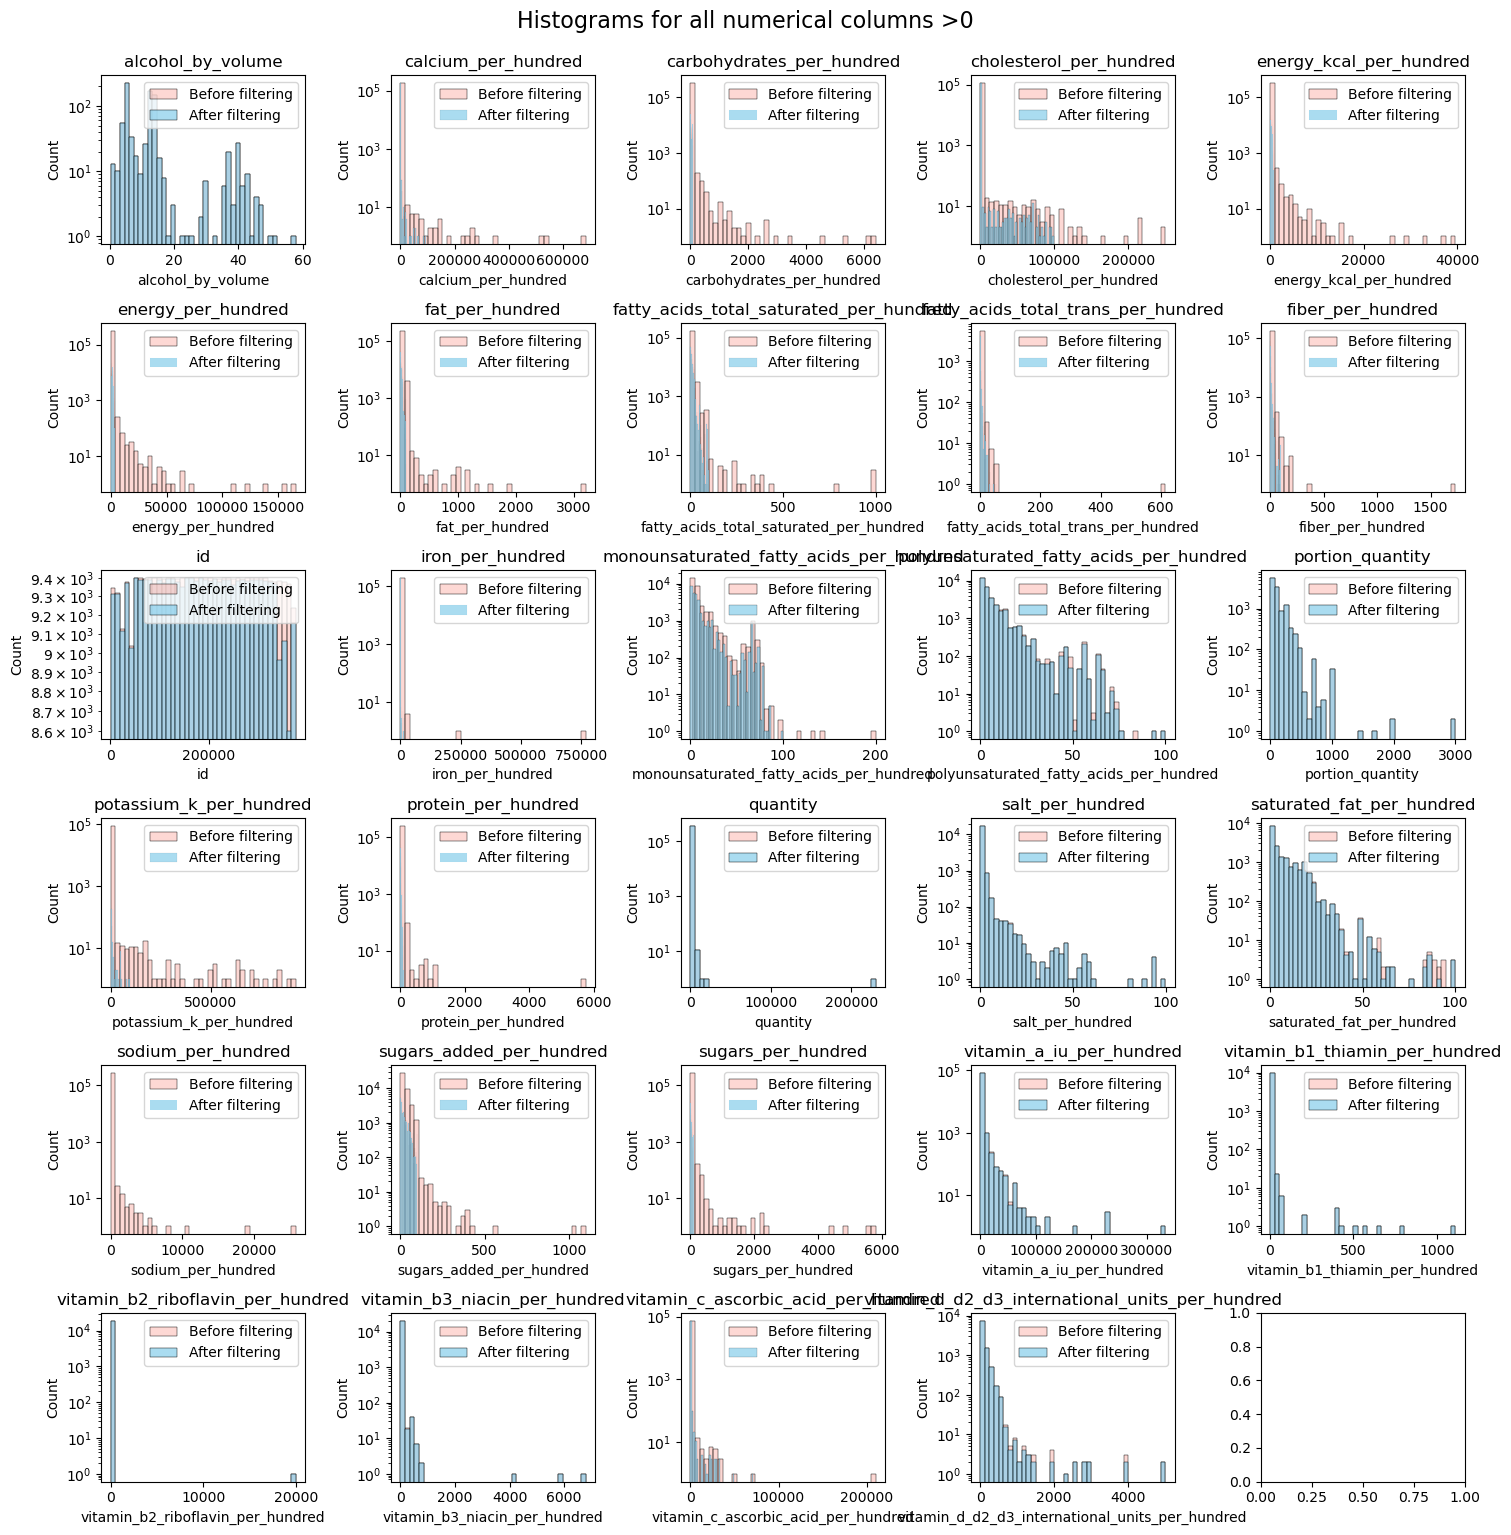

In [47]:
# Let's plot the data after and before filtering
fig, axes = plt.subplots(6, 5, figsize=(15, 15))
axes = axes.flatten()

for ax, col in zip(axes, num_col):
    # Before filtering
    sns.histplot(df.loc[df[col] > 0, col],
                 ax=ax, bins=40, color="salmon", alpha=0.3, label="Before filtering")
    
    # After filtering
    sns.histplot(df_filtered.loc[df_filtered[col] > 0, col],
                 ax=ax, bins=40, color="skyblue", alpha=0.7, label="After filtering")
    
    ax.set_title(col)
    ax.set_yscale("log")
    ax.legend()


plt.tight_layout()
plt.suptitle("Histograms for all numerical columns >0", y=1.02, size=16)
plt.show()

We observe that we did remove some of extreme values for several per_hundred columns. Interestingly, there are some columns (such as calcium and carbohydrate) were it seems that most values were removed, while for others (salt_per_hundred and saturated_fat_per_hundred) we barely removed any values. We can replot only the filtered values to inspect this in more detail

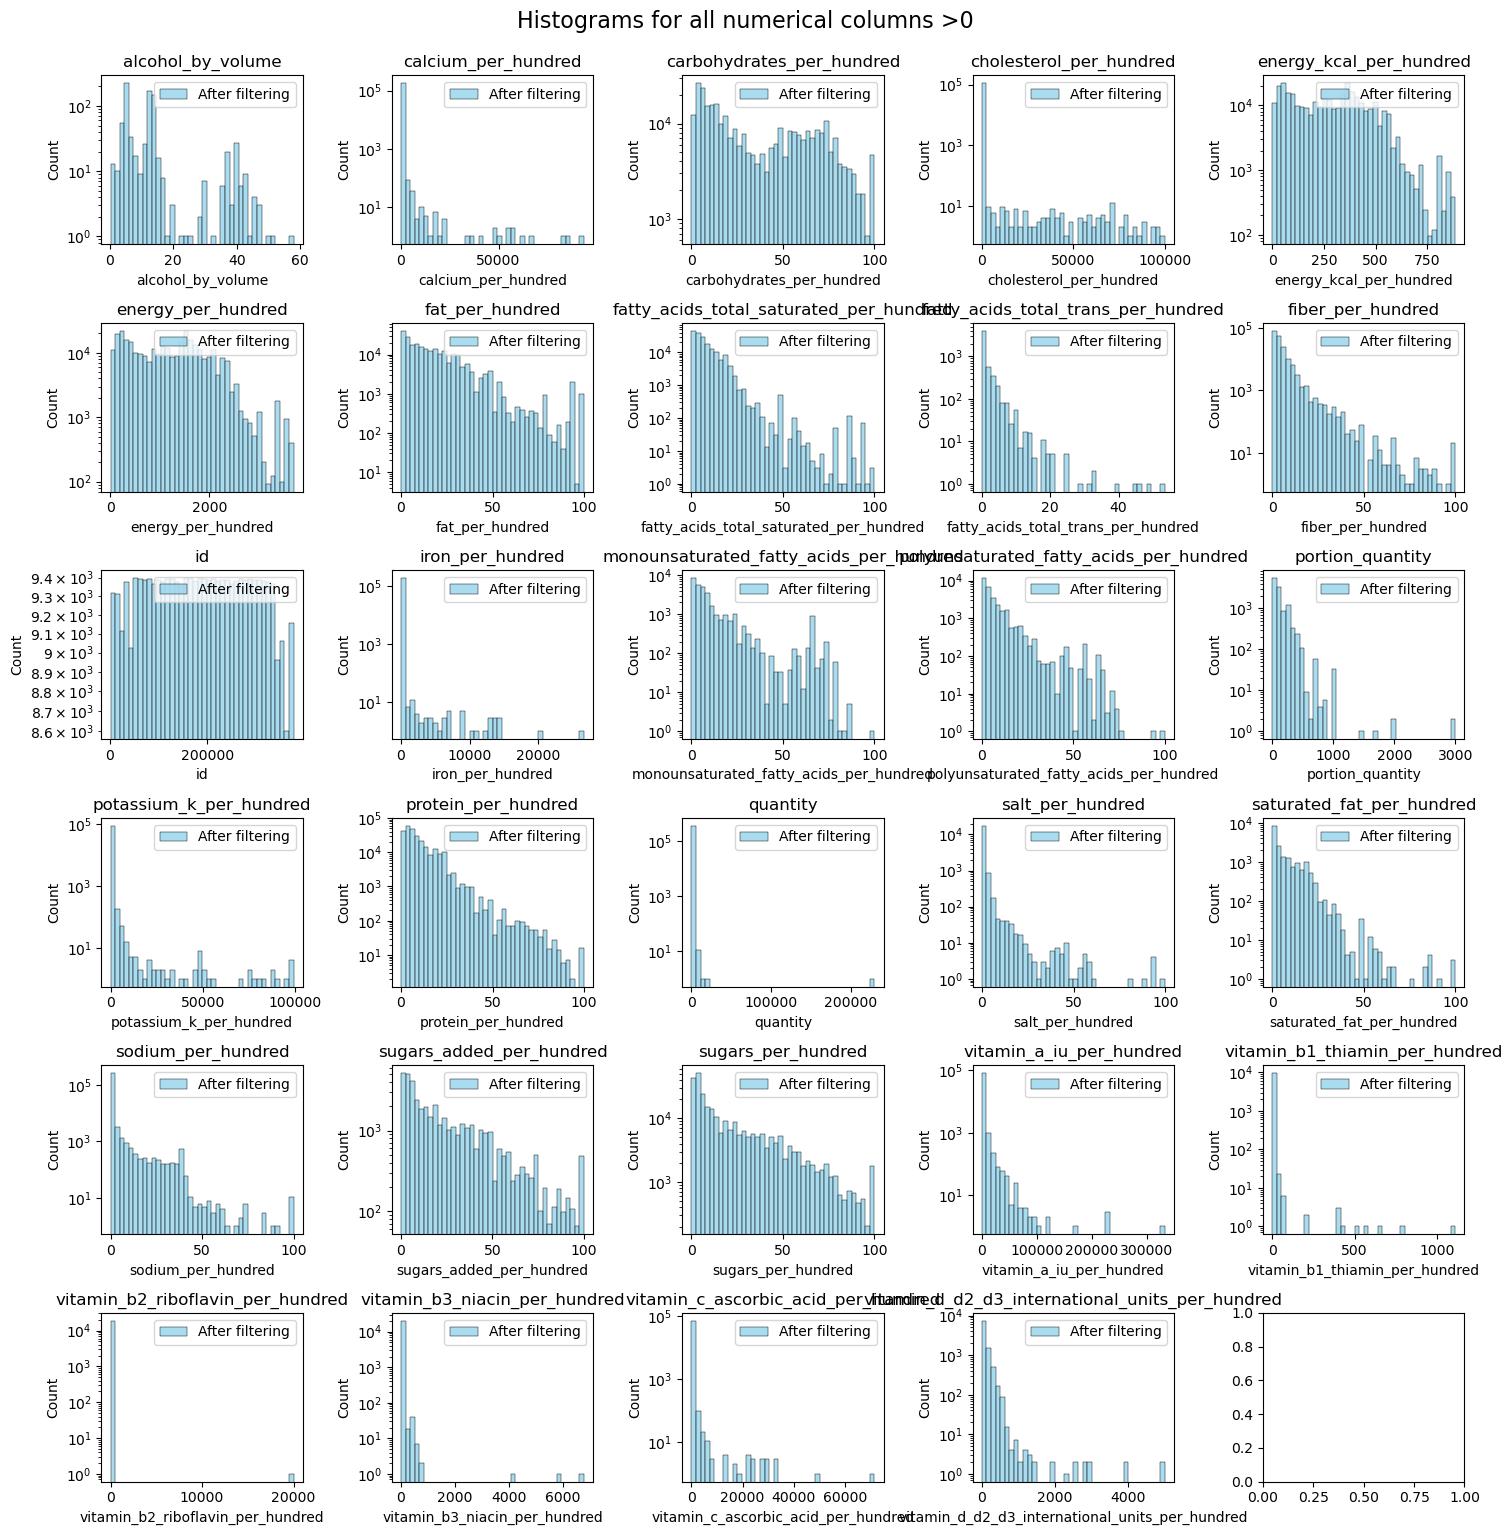

In [48]:
# Let's plot the data only after filtering
fig, axes = plt.subplots(6, 5, figsize=(15, 15))
axes = axes.flatten()

for ax, col in zip(axes, num_col):
    sns.histplot(df_filtered.loc[df_filtered[col] > 0, col],
                 ax=ax, bins=40, color="skyblue", alpha=0.7, label="After filtering")
    
    ax.set_title(col)
    ax.set_yscale("log")
    ax.legend()


plt.tight_layout()
plt.suptitle("Histograms for all numerical columns >0", y=1.02, size=16)
plt.show()

This confirms what we saw before, some columns likely contained mistakes (wrong units) and were filtered out. This is especially the case for the calcium and carbohydrate columns for instance. 

#### **1b) Adressing inconsistencies and errors using related columns** 

As mentioned above, some columns in our data are related to each other or pose constraints on one another. I will investigate the three cases below, identify potential inconsistencies and address them any errors in the data
- The bulk of most products is made up of the four main macronutrients (fat, protein, carbohydrates and fiber). In the previous subtask we checked that each of their "_per_hundred_" value is at most 100g. We can equally apply the same logic for their combined amount. For example, a product with 64g of carbohydrates, 43g of protein and 12g of fat would give us a total of 119g of macronutrients in 100g of produce. Clearly that is not realistic.
- The column "energy_per_hundred" measures the energy content in kJ. Analyze its relationship with the column "energy_kcal_per_hundred".
- Each of the four macronutrients has a specific energy content (fat 37 kJ/g, protein and carbohydrates 17 kJ/g, fibre 8 kJ/g). Calculate the energy provided by these four macronutrients and compare this to the "energy_per_hundred"-column. Keep in mind that we are only looking at a subset of all the nutrients.

#### Checking that the total macronutrient content is below 100g

We will start by adressing the first case. To do this, we will transform all values in the columns in grams and check if the sum of fat, protein, carbohydrates and fiber is above 100. We will make histograms to visualize the data along the way. 

In [49]:
# Transform all values in gram

col_hundred_filtered = pd.Series(['carbohydrates_per_hundred','fat_per_hundred',
                              'fiber_per_hundred', 'protein_per_hundred'])

names = col_hundred_filtered.str.replace('_per_hundred', '', regex=False)

gram = pd.DataFrame(columns = names, index=df_filtered.index) 

# for each name in the list, compute the value in grams
for name in names:
    name_hundred = name + "_per_hundred"
    name_unit = name + "_unit"
    gram[name] = df_filtered[name_hundred] / df_filtered[name_unit].map({
        "g": 1,
        "mg": 1000,
        "µg": 1000_000
    })

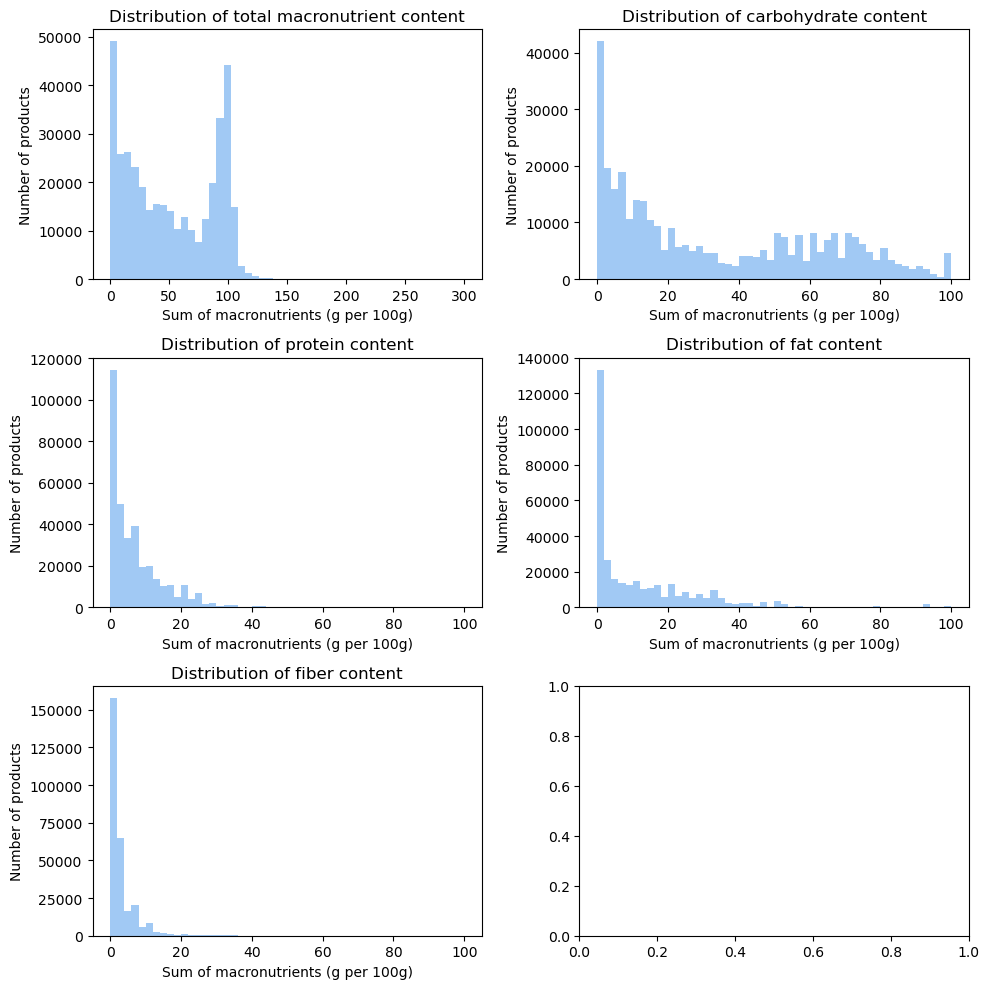

In [50]:
# Plot the total macronutrient content in a histogram 

fig, axes = plt.subplots(3,2, figsize=(10, 10))

axes[0,0].hist(gram.sum(axis=1), bins=50)
axes[0,0].set_xlabel("Sum of macronutrients (g per 100g)")
axes[0,0].set_ylabel("Number of products")
axes[0,0].set_title("Distribution of total macronutrient content")

axes[0,1].hist(gram.carbohydrates, bins=50)
axes[0,1].set_xlabel("Sum of macronutrients (g per 100g)")
axes[0,1].set_ylabel("Number of products")
axes[0,1].set_title("Distribution of carbohydrate content")

axes[1,0].hist(gram.protein, bins=50)
axes[1,0].set_xlabel("Sum of macronutrients (g per 100g)")
axes[1,0].set_ylabel("Number of products")
axes[1,0].set_title("Distribution of protein content")

axes[1,1].hist(gram.fat, bins=50)
axes[1,1].set_xlabel("Sum of macronutrients (g per 100g)")
axes[1,1].set_ylabel("Number of products")
axes[1,1].set_title("Distribution of fat content")

axes[2,0].hist(gram.fiber, bins=50)
axes[2,0].set_xlabel("Sum of macronutrients (g per 100g)")
axes[2,0].set_ylabel("Number of products")
axes[2,0].set_title("Distribution of fiber content")

plt.tight_layout()
plt.show()

We see on the first histogram that a small percentage of rows have a total macronutrient content that is above 100. This is likely due to an error in the total carbohydrate content, as there seems to be a lot of values that are around 100.

Let's now create a filter to remove all rows that have a sum of macronutrients above 100.

In [51]:
filter_macronutrients = gram.sum(axis=1) > 100.5

print(filter_macronutrients.sum(), "rows are incorrect")
print("This corresponds to", filter_macronutrients.sum() / len(df_filtered) * 100, "% of the data")

print("data frame shape before removing rows", df_filtered.shape)

df_filtered = df_filtered[~filter_macronutrients]

print("data frame shape after removing rows", df_filtered.shape)

21746 rows are incorrect
This corresponds to 5.832497411772279 % of the data
data frame shape before removing rows (372842, 77)
data frame shape after removing rows (351096, 77)


#### Checking that the energy value is consistent between the kJ and kcal columns

We will now make sure that the energy value (that is contained in the kj and kcal columns) is consistent by using the relationship between the two columns. 

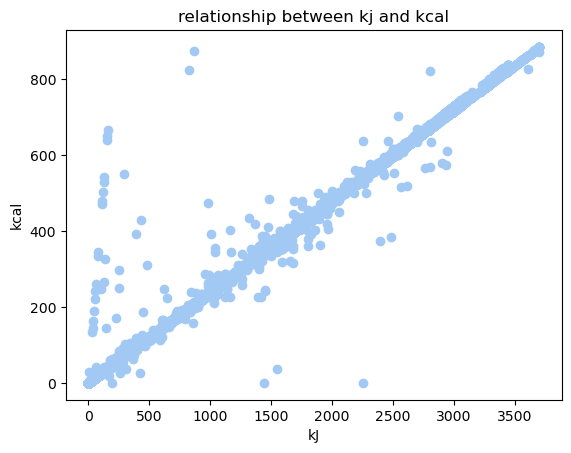

In [52]:
#Let's plot a scatter plot. The relationship between the two columns should be linear

plt.scatter(df_filtered["energy_per_hundred"], df_filtered["energy_kcal_per_hundred"])
plt.xlabel("kJ")
plt.ylabel("kcal")
plt.title("relationship between kj and kcal")
plt.show()

We see that the majority of values are as expected (i.e., linear relationship between energy in kcal and energy in kj). However, there are some values that divert from the line. We should remove them. 

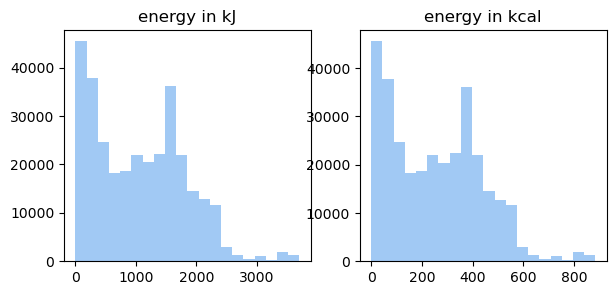

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(7,3))

axes[0].hist(df_filtered.energy_per_hundred, bins=20)
axes[0].set_title("energy in kJ")
axes[1].hist(df_filtered.energy_kcal_per_hundred, bins=20)
axes[1].set_title("energy in kcal")
plt.show()

I use this graph as a sanity check, to make sure that the energy in kJ is 4.184 bigger then the energy in kcal.

Let's now create a filter to remove the data.

In [54]:
filter_calories = abs(df_filtered["energy_per_hundred"] - 4.184 * df_filtered["energy_kcal_per_hundred"]) > 0.1

print(filter_calories.sum(), "values are incorrect")
print("This corresponds to ", filter_calories.sum() / len(df_filtered) * 100, "% of the data")

print("df shape before filtering:", df_filtered.shape)

df_filtered = df_filtered[~filter_calories]

print("df shape after filtering:", df_filtered.shape)



23067 values are incorrect
This corresponds to  6.5699979492788305 % of the data
df shape before filtering: (351096, 77)
df shape after filtering: (328029, 77)


Let's plot the data again to make sure our filtering worked. 

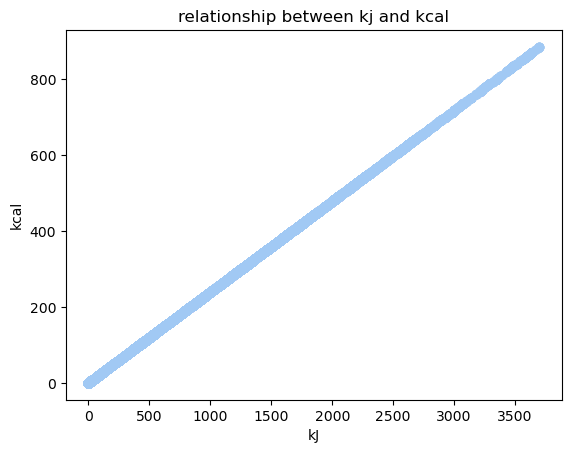

In [40]:
plt.scatter(df_filtered["energy_per_hundred"], df_filtered["energy_kcal_per_hundred"])
plt.xlabel("kJ")
plt.ylabel("kcal")
plt.title("relationship between kj and kcal")
plt.show()

In [ ]:
filter_calories = abs(df_filtered["energy_per_hundred"] - 4.184 * df_filtered["energy_kcal_per_hundred"]) > 0.1

print(filter_calories.sum(), "values are incorrect")

print("df shape before filtering:", df_filtered.shape)

df_filtered = df_filtered[~filter_calories]

print("df shape after filtering:", df_filtered.shape)

In [ ]:
# Let's plot the relationship between the two variables again
plt.scatter(df_filtered["energy_per_hundred"], df_filtered["energy_kcal_per_hundred"])
plt.xlabel("kJ")
plt.ylabel("kcal")
plt.title("relationship between kj and kcal")


We see that the relationship is now perfectly linear and that we removed any incorrect values.

#### Filtering based on total energy content. 
Each of the four macronutrients has a specific energy content (fat 37 kJ/g, protein and carbohydrates 17 kJ/g, fibre 8 kJ/g). 
We can calculate the energy provided by these four macronutrients and compare this to the "energy_per_hundred"-column. It should be smaller than the energy in that column.

Let's first start by calculating the sum of energy contained in the four mentioned column and plotting it agains the total energy. 

In [55]:
macronutrients = pd.Series(["fat_per_hundred", "protein_per_hundred", "carbohydrates_per_hundred", "fiber_per_hundred"])

energy_macronutrients = pd.DataFrame(index=df_filtered.index, columns=macronutrients.str.replace('_per_hundred', '', regex=False))

total_energy = df_filtered[macronutrients].apply({
    "fat_per_hundred": lambda x: x*37,
    "protein_per_hundred": lambda x: x*17,
    "carbohydrates_per_hundred": lambda x: x*17,
    "fiber_per_hundred": lambda x: x*8    
}).sum(axis=1)

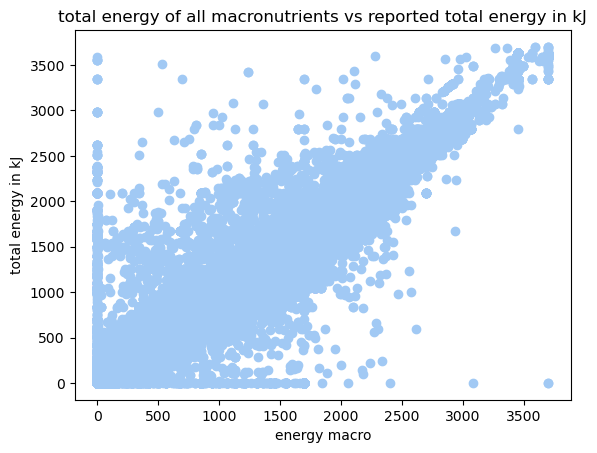

In [43]:
plt.scatter(total_energy, df_filtered["energy_per_hundred"])
plt.title("total energy of all macronutrients vs reported total energy in kJ")
plt.xlabel("energy macro")
plt.ylabel("total energy in kJ")
plt.show()

Let's now create a filter to remove any rows where the energy of macronutrients is bigger than the energy_per_hundred (with a 5% tolerance)

In [66]:
filter_energy = (total_energy > (df_filtered["energy_per_hundred"] + 0.05 * df_filtered["energy_per_hundred"]))

print(filter_energy.sum(), "values are incorrect and contain too much macronutrient energy")
print("this is", filter_energy.sum() / len(df_filtered) * 100, "% of the data")

88921 values are incorrect and contain too much macronutrient energy
this is 27.107664261391523 % of the data
shape before filtering (328029, 77)


We actually see that we would be removing almost 30% of our data using this strategy. This might be too much. We can try increasing the tolerance to see if we find a better option.

In [68]:
filter_energy = (total_energy > (df_filtered["energy_per_hundred"] + 0.10 * df_filtered["energy_per_hundred"]))

print(filter_energy.sum(), "values are incorrect and contain too much macronutrient energy")
print("this is", filter_energy.sum() / len(df_filtered) * 100, "% of the data")

39858 values are incorrect and contain too much macronutrient energy
this is 12.150754963737963 % of the data
shape before filtering (328029, 77)


Using a 10% tolerance, we are now removint 12% of the data, which seems more manageable. Let's keep this filter.

In [69]:
print("shape before filtering", df_filtered.shape)
df_filtered = df_filtered[~filter_energy]
print("shape after filtering", df_filtered.shape)

shape after filtering (288171, 77)


Let's plot the data again after cleaning.

In [154]:
energy_macronutrients = pd.DataFrame(index=df_filtered.index, columns=macronutrients.str.replace('_per_hundred', '', regex=False))

total_energy = df_filtered[macronutrients].apply({
    "fat_per_hundred": lambda x: x*37,
    "protein_per_hundred": lambda x: x*17,
    "carbohydrates_per_hundred": lambda x: x*17,
    "fiber_per_hundred": lambda x: x*8    
}).sum(axis=1)

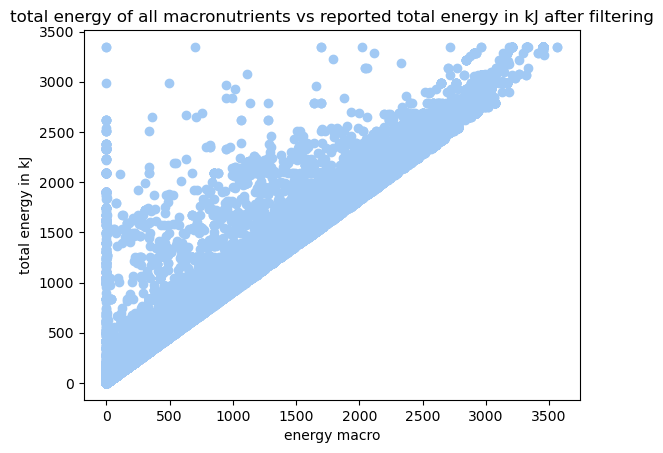

In [156]:
plt.scatter(total_energy, df_filtered["energy_per_hundred"])
plt.title("total energy of all macronutrients vs reported total energy in kJ after filtering")
plt.xlabel("energy macro")
plt.ylabel("total energy in kJ")
plt.show()

Much better, it seems our cleaning strategy worked!

### **2) Removing outliers**

Now that we have adressed errors in our data, we can have a look at strategies to remove any extreme values (or outliers) in the numerical variables.

Let's first start by plotting these columns again to see what would be the best options.

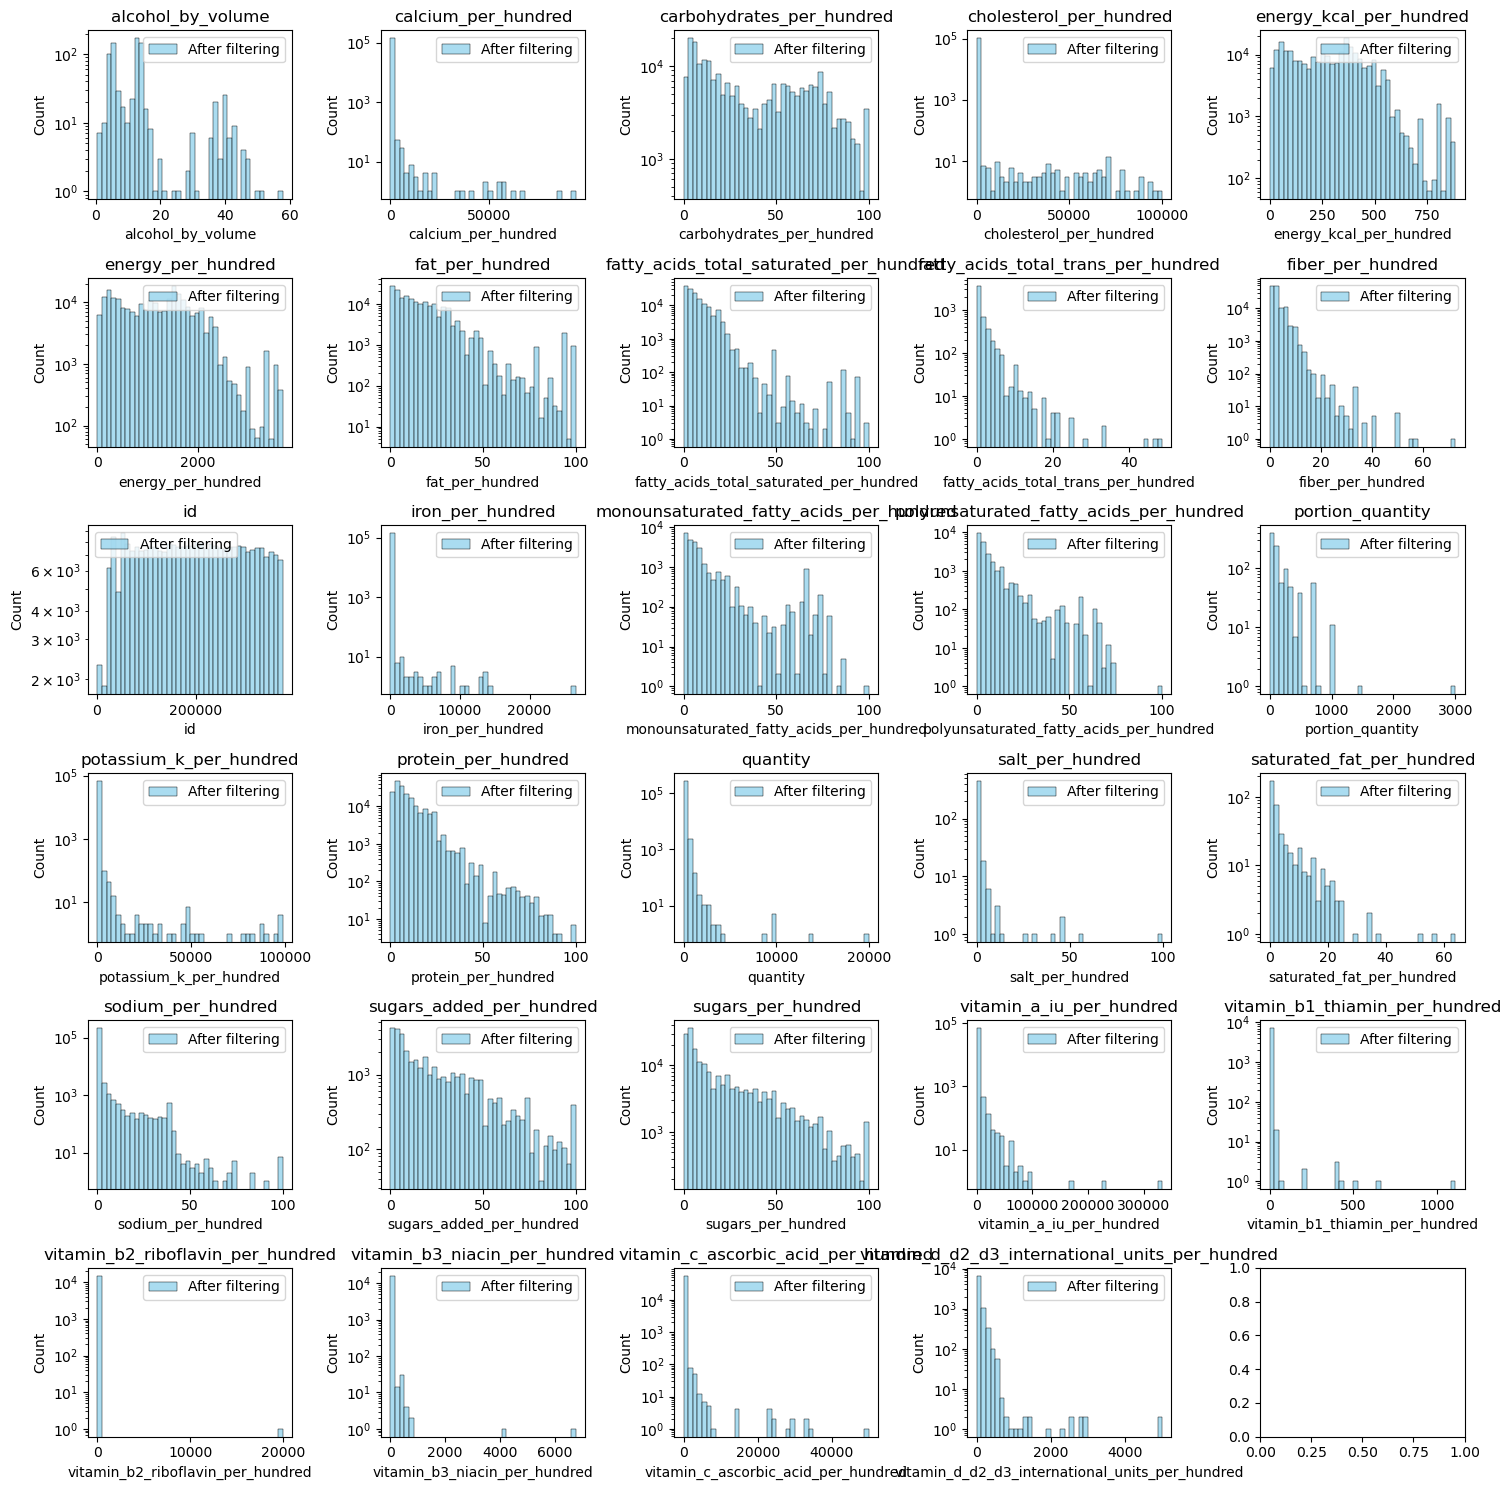

In [73]:
num_col = df_filtered.select_dtypes(include=["float64", "int64"]).columns

fig, axes = plt.subplots(6, 5, figsize=(15, 15))
axes = axes.flatten()

for ax, col in zip(axes, num_col):
    sns.histplot(df_filtered.loc[df_filtered[col] > 0, col],
                 ax=ax, bins=40, color="skyblue", alpha=0.7)
    
    ax.set_title(col)
    ax.set_yscale("log")
    
plt.tight_layout()
plt.show()

As most of the data does not follow a Gaussian distribution, one approach we could take is to filter out outliers based on quantiles.
For instance, we could remove the top 1% of values for each numerical variable. Filtering out the lowest 1% would likely not make sense, as many of the values are equal to 0.

We will start by calculating a threshold for each column corresponding to the 99th percentile.

In [144]:
percentile = df_filtered[num_col].quantile(0.99)
print(percentile)

alcohol_by_volume                                       0.0000
calcium_per_hundred                                   843.0000
carbohydrates_per_hundred                             100.0000
cholesterol_per_hundred                               167.0000
energy_kcal_per_hundred                               800.0000
energy_per_hundred                                   3347.2000
fat_per_hundred                                        93.3300
fatty_acids_total_saturated_per_hundred                26.3200
fatty_acids_total_trans_per_hundred                     0.8000
fiber_per_hundred                                      10.7000
id                                                 372409.3000
iron_per_hundred                                       10.7100
monounsaturated_fatty_acids_per_hundred                66.6700
polyunsaturated_fatty_acids_per_hundred                57.1400
portion_quantity                                        0.0000
potassium_k_per_hundred                              13

Here we might want to exclude the alcohol_by_volume column from this approach, as the majority of the values are 0 and any value bigger than this might actually be meaningful. 

However, for the other columns, let's use this approach to filter our data set. 

In [148]:
filt_col = [col for col in num_col if col != "alcohol_by_volume"]
filter_outliers = df_filtered[filt_col].apply(lambda x: x > percentile[x.name])

# creating a row filter
row_filter = ~filter_outliers.any(axis=1)
print((~row_filter).sum(), "rows will be removed")
print("This is", (~row_filter).sum() / len(df_filtered) * 100, "% of the data")

29112 rows will be removed
This is 10.102335071884402 % of the data


In [152]:
df_filtered = df_filtered[row_filter]

Alright, let's now finally save the new data frame as a csv file.

## **Saving the data**

In [ ]:
# Save new data frame as data_clean
df_filtered.to_csv("data_clean.csv", index=False)